# Tourism Experience Analytics Complete Project

This single notebook covers data understanding, cleaning, integration, univariate EDA, bivariate EDA, multivariate EDA, rating prediction, visit-mode classification, and attraction recommendations. Run the cells from top to bottom.

In [1]:
# Colab setup: run once. This supports direct upload of Tourism Dataset-20260904T170958Z-1-001.zip.
!pip -q install pandas numpy matplotlib seaborn scikit-learn openpyxl joblib

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import zipfile

# Upload your data ZIP to Colab, then run this cell.
from google.colab import files
uploaded = files.upload()

DATA_ZIP = Path('/content/Tourism Dataset-20260904T170958Z-1-001.zip')
DATA_ROOT = Path('/content/tourism_project')
DATA_ROOT.mkdir(parents=True, exist_ok=True)
if DATA_ZIP.exists() and not (DATA_ROOT / 'Tourism Dataset').exists():
    with zipfile.ZipFile(DATA_ZIP, 'r') as archive:
        archive.extractall(DATA_ROOT)

# The uploaded ZIP extracts directly to: /content/tourism_project/Tourism Dataset/
RAW = DATA_ROOT / 'Tourism Dataset'
PROCESSED = DATA_ROOT / 'processed'
PROCESSED.mkdir(parents=True, exist_ok=True)
ROOT = DATA_ROOT
RANDOM_STATE = 42
pd.set_option('display.max_columns', 50)
print('Dataset path:', RAW)
print('Transaction file found:', (RAW / 'Transaction.xlsx').exists())

Saving Tourism Dataset-20260904T170958Z-1-001.zip to Tourism Dataset-20260904T170958Z-1-001.zip
Dataset path: /content/tourism_project/Tourism Dataset
Transaction file found: True


## 1 Data Understanding

In [2]:
files = {'transaction': RAW/'Transaction.xlsx', 'user': RAW/'User.xlsx', 'city': RAW/'City.xlsx', 'country': RAW/'Country.xlsx', 'region': RAW/'Region.xlsx', 'continent': RAW/'Continent.xlsx', 'mode': RAW/'Mode.xlsx', 'type': RAW/'Type.xlsx', 'item': RAW/'Item.xlsx', 'updated_item': RAW/'Additional_Data_for_Attraction_Sites'/'Updated_Item.xlsx'}
tables = {name: pd.read_excel(path) for name, path in files.items()}
{name: df.shape for name, df in tables.items()}

{'transaction': (52930, 7),
 'user': (33530, 5),
 'city': (9143, 3),
 'country': (165, 3),
 'region': (22, 3),
 'continent': (6, 2),
 'mode': (6, 2),
 'type': (17, 2),
 'item': (30, 5),
 'updated_item': (1698, 5)}

In [3]:
def audit_table(name, df):
    key = df.columns[0]
    return {'dataset':name, 'rows':len(df), 'columns':len(df.columns), 'missing_cells':int(df.isna().sum().sum()), 'duplicate_rows':int(df.duplicated().sum()), 'key_column':key, 'key_is_unique':df[key].is_unique}
audit = pd.DataFrame([audit_table(name, df) for name, df in tables.items()])
display(audit)
display(tables['transaction'].head())

,dataset,rows,columns,missing_cells,duplicate_rows,key_column,key_is_unique
0,transaction,52930,7,0,0,TransactionId,True
1,user,33530,5,4,0,UserId,True
2,city,9143,3,1,0,CityId,True
3,country,165,3,0,0,CountryId,True
4,region,22,3,0,0,Region,True
5,continent,6,2,0,0,ContinentId,True
6,mode,6,2,0,0,VisitModeId,True
7,type,17,2,0,0,AttractionTypeId,True
8,item,30,5,0,0,AttractionId,True
9,updated_item,1698,5,0,0,AttractionId,True


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating
0,3,70456,2022,10,2,640,5
1,8,7567,2022,10,4,640,5
2,9,79069,2022,10,3,640,5
3,10,31019,2022,10,3,640,3
4,15,43611,2022,10,2,640,3


In [4]:
checks = [('Transaction.UserId -> User.UserId', tables['transaction'].UserId, tables['user'].UserId), ('Transaction.AttractionId -> Item.AttractionId', tables['transaction'].AttractionId, tables['item'].AttractionId), ('User.CityId -> City.CityId', tables['user'].CityId, tables['city'].CityId), ('Item.AttractionTypeId -> Type.AttractionTypeId', tables['item'].AttractionTypeId, tables['type'].AttractionTypeId)]
pd.DataFrame([{'relationship':label, 'orphan_rows':int((~left.isin(right)).sum())} for label,left,right in checks])

,relationship,orphan_rows
0,Transaction.UserId -> User.UserId,0
1,Transaction.AttractionId -> Item.AttractionId,0
2,User.CityId -> City.CityId,4
3,Item.AttractionTypeId -> Type.AttractionTypeId,0


## 2 Cleaning and Preprocessing

In [5]:
# Cleaning decision: remove exact duplicate records only. Raw Excel workbooks remain unchanged.
cleaned = {name: df.drop_duplicates().copy() for name, df in tables.items() if name != 'updated_item'}
cleaning_log = pd.DataFrame([{'dataset':name, 'before_rows':len(tables[name]), 'after_rows':len(df), 'rows_affected':len(tables[name])-len(df), 'reason':'Removed exact duplicates only'} for name,df in cleaned.items()])
display(cleaning_log)
transaction = cleaned['transaction']
display(pd.Series({'invalid_rating_rows':((transaction.Rating < 1) | (transaction.Rating > 5)).sum(), 'invalid_month_rows':((transaction.VisitMonth < 1) | (transaction.VisitMonth > 12)).sum()}))

,dataset,before_rows,after_rows,rows_affected,reason
0,transaction,52930,52930,0,Removed exact duplicates only
1,user,33530,33530,0,Removed exact duplicates only
2,city,9143,9143,0,Removed exact duplicates only
3,country,165,165,0,Removed exact duplicates only
4,region,22,22,0,Removed exact duplicates only
5,continent,6,6,0,Removed exact duplicates only
6,mode,6,6,0,Removed exact duplicates only
7,type,17,17,0,Removed exact duplicates only
8,item,30,30,0,Removed exact duplicates only


,0
invalid_rating_rows,0
invalid_month_rows,0


## 3 Data Integration

In [7]:
t = cleaned
tx = t['transaction'].merge(t['mode'].rename(columns={'VisitMode':'VisitModeLabel'}), left_on='VisitMode', right_on='VisitModeId', how='left')
tx['VisitMode'] = tx['VisitModeLabel']
tx = tx.drop(columns=['VisitModeId','VisitModeLabel'])
user_geo = t['user'].merge(t['city'].rename(columns={'CityId':'UserCityId','CityName':'UserCity'}), left_on='CityId', right_on='UserCityId', how='left')
user_geo = user_geo.merge(t['country'].rename(columns={'Country':'UserCountry','RegionId':'UserRegionId'}),left_on='CountryId_y', right_on='CountryId',how='left').merge(t['region'].rename(columns={'RegionId':'UserRegionId','Region':'UserRegion','ContinentId':'UserContinentId'}),on='UserRegionId',how='left').merge(t['continent'].rename(columns={'ContinentId':'UserContinentId','Continent':'UserContinent'}),on='UserContinentId',how='left')
user_geo = user_geo[['UserId','UserCity','UserCountry','UserRegion','UserContinent']]

In [8]:
attraction_geo = t['item'].merge(t['type'],on='AttractionTypeId',how='left').merge(t['city'].rename(columns={'CityId':'AttractionCityId','CityName':'AttractionCity','CountryId':'AttractionCountryId'}),on='AttractionCityId',how='left')
attraction_geo = attraction_geo.merge(t['country'],left_on='AttractionCountryId',right_on='CountryId',how='left').merge(t['region'],on='RegionId',how='left').merge(t['continent'],on='ContinentId',how='left').rename(columns={'Country':'AttractionCountry','Region':'AttractionRegion','Continent':'AttractionContinent'})
attraction_geo = attraction_geo[['AttractionId','Attraction','AttractionType','AttractionCity','AttractionCountry','AttractionRegion','AttractionContinent','AttractionAddress']]
master = tx.merge(user_geo,on='UserId',how='left',validate='many_to_one').merge(attraction_geo,on='AttractionId',how='left',validate='many_to_one')
assert len(master) == len(tx), 'Unexpected row multiplication'
master.to_csv(PROCESSED/'master_dataset.csv',index=False)
master.head()

,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating,UserCity,UserCountry,UserRegion,UserContinent,Attraction,AttractionType,AttractionCity,AttractionCountry,AttractionRegion,AttractionContinent,AttractionAddress
0,3,70456,2022,10,Couples,640,5,Guildford,Australia,Australia,Australia & Oceania,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Douala,Cameroon,Central Africa,Africa,"Jl. Monkey Forest, Ubud 80571 Indonesia"
1,8,7567,2022,10,Friends,640,5,Ontario,Canada,Northern America,America,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Douala,Cameroon,Central Africa,Africa,"Jl. Monkey Forest, Ubud 80571 Indonesia"
2,9,79069,2022,10,Family,640,5,Brazil,United States,Northern America,America,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Douala,Cameroon,Central Africa,Africa,"Jl. Monkey Forest, Ubud 80571 Indonesia"
3,10,31019,2022,10,Family,640,3,Zurich,Canada,Northern America,America,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Douala,Cameroon,Central Africa,Africa,"Jl. Monkey Forest, Ubud 80571 Indonesia"
4,15,43611,2022,10,Couples,640,3,Manchester,United States,Northern America,America,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Douala,Cameroon,Central Africa,Africa,"Jl. Monkey Forest, Ubud 80571 Indonesia"


## 4 EDA Univariate Analysis

One variable at a time: distributions of rating, visit mode, year, month, and attraction type.

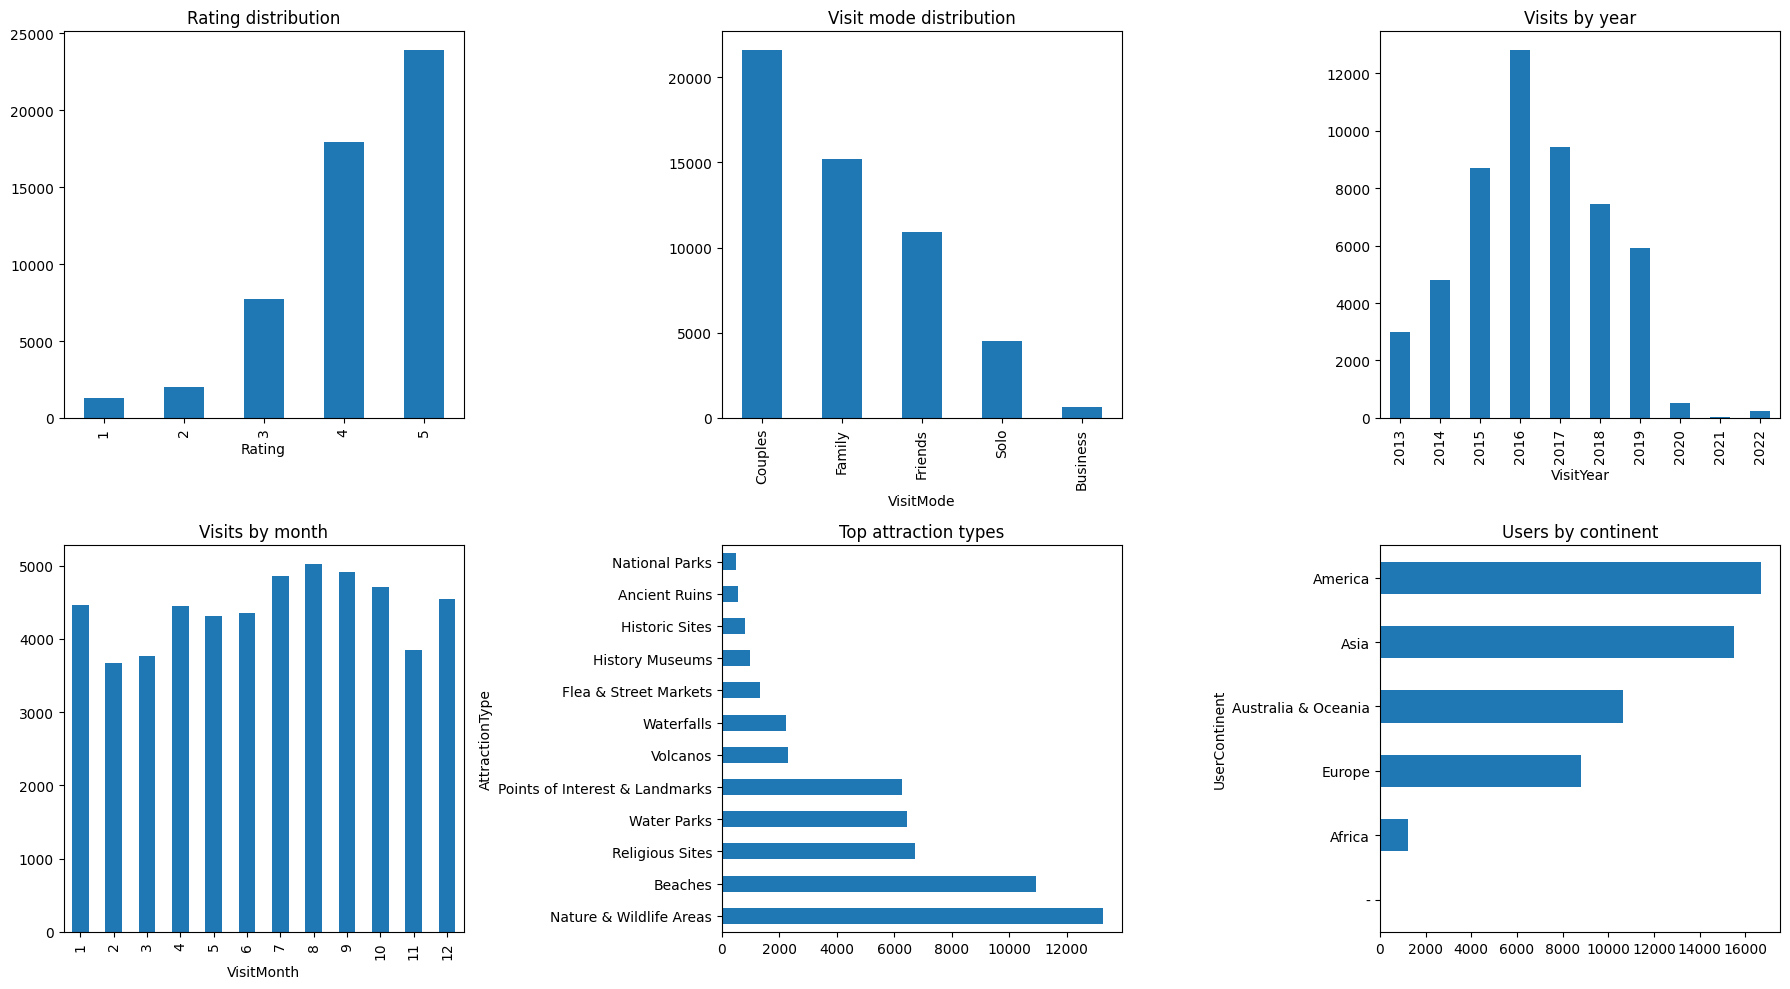

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
master['Rating'].value_counts().sort_index().plot.bar(ax=axes[0,0],title='Rating distribution')
master['VisitMode'].value_counts().plot.bar(ax=axes[0,1],title='Visit mode distribution')
master['VisitYear'].value_counts().sort_index().plot.bar(ax=axes[0,2],title='Visits by year')
master['VisitMonth'].value_counts().sort_index().plot.bar(ax=axes[1,0],title='Visits by month')
master['AttractionType'].value_counts().head(12).plot.barh(ax=axes[1,1],title='Top attraction types')
master.groupby('UserContinent').size().sort_values().plot.barh(ax=axes[1,2],title='Users by continent')
plt.tight_layout(); plt.show()

## 5 EDA Bivariate Analysis

Relationships between two variables: rating by mode, demand by attraction type, and seasonality by visit mode.

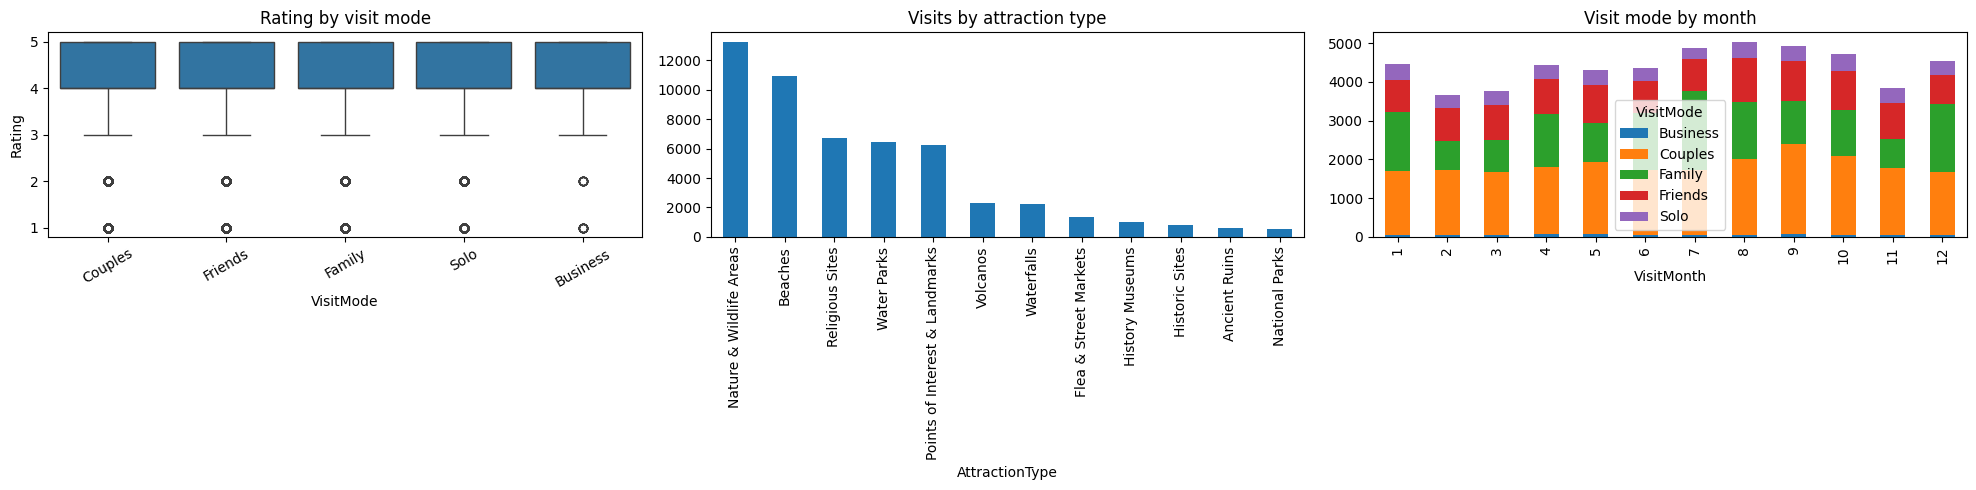

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.boxplot(data=master, x='VisitMode', y='Rating', ax=axes[0]); axes[0].set_title('Rating by visit mode'); axes[0].tick_params(axis='x',rotation=30)
master.groupby('AttractionType').size().sort_values(ascending=False).head(12).plot.bar(ax=axes[1],title='Visits by attraction type')
pd.crosstab(master['VisitMonth'], master['VisitMode']).plot(kind='bar', stacked=True, ax=axes[2], title='Visit mode by month')
plt.tight_layout(); plt.show()

In [11]:
top_attractions = master.groupby('Attraction').agg(visits=('TransactionId','size'), average_rating=('Rating','mean')).sort_values('visits',ascending=False).head(15)
display(top_attractions)
master.groupby('AttractionType').agg(visits=('TransactionId','size'), average_rating=('Rating','mean')).sort_values('visits',ascending=False).head(15)

,visits,average_rating
Attraction,,
Sacred Monkey Forest Sanctuary,13198,4.267086
Waterbom Bali,6429,4.646601
Tegalalang Rice Terrace,5815,4.157524
Uluwatu Temple,3359,4.219411
Tanah Lot Temple,3352,4.194809
Sanur Beach,3044,3.976347
Seminyak Beach,2914,3.800618
Kuta Beach - Bali,2765,3.415190
Merapi Volcano,2235,4.079195


,visits,average_rating
AttractionType,,
Nature & Wildlife Areas,13251,4.266848
Beaches,10917,3.845745
Religious Sites,6711,4.207123
Water Parks,6429,4.646601
Points of Interest & Landmarks,6252,4.131158
Volcanos,2318,4.101381
Waterfalls,2245,3.897105
Flea & Street Markets,1324,3.869335
History Museums,978,4.256646


## 6 EDA Multivariate Analysis

Three or more variables together: season, visit mode, rating, and attraction type.

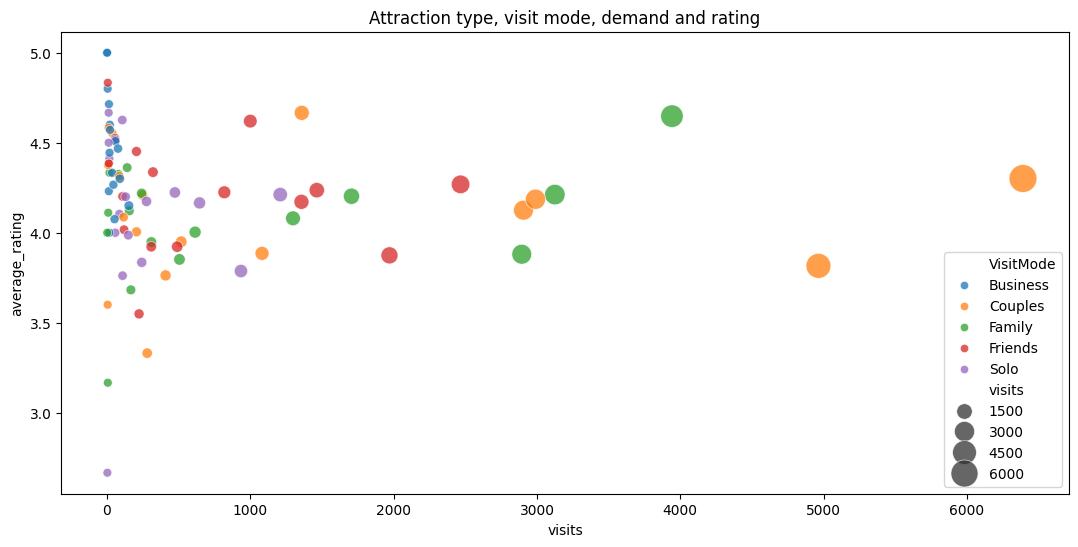

,AttractionType,VisitMode,visits,average_rating
41,Nature & Wildlife Areas,Couples,6391,4.301205
11,Beaches,Couples,4964,3.815874
76,Water Parks,Family,3942,4.647641
42,Nature & Wildlife Areas,Family,3125,4.211840
56,Religious Sites,Couples,2990,4.185953
51,Points of Interest & Landmarks,Couples,2906,4.125258
12,Beaches,Family,2894,3.880442
43,Nature & Wildlife Areas,Friends,2467,4.268747
13,Beaches,Friends,1971,3.874176
57,Religious Sites,Family,1706,4.202814


In [12]:
multi = master.groupby(['AttractionType','VisitMode']).agg(visits=('TransactionId','size'), average_rating=('Rating','mean')).reset_index()
plt.figure(figsize=(13,6))
sns.scatterplot(data=multi, x='visits', y='average_rating', hue='VisitMode', size='visits', sizes=(40,400), alpha=.75)
plt.title('Attraction type, visit mode, demand and rating'); plt.show()
display(multi.sort_values('visits',ascending=False).head(20))

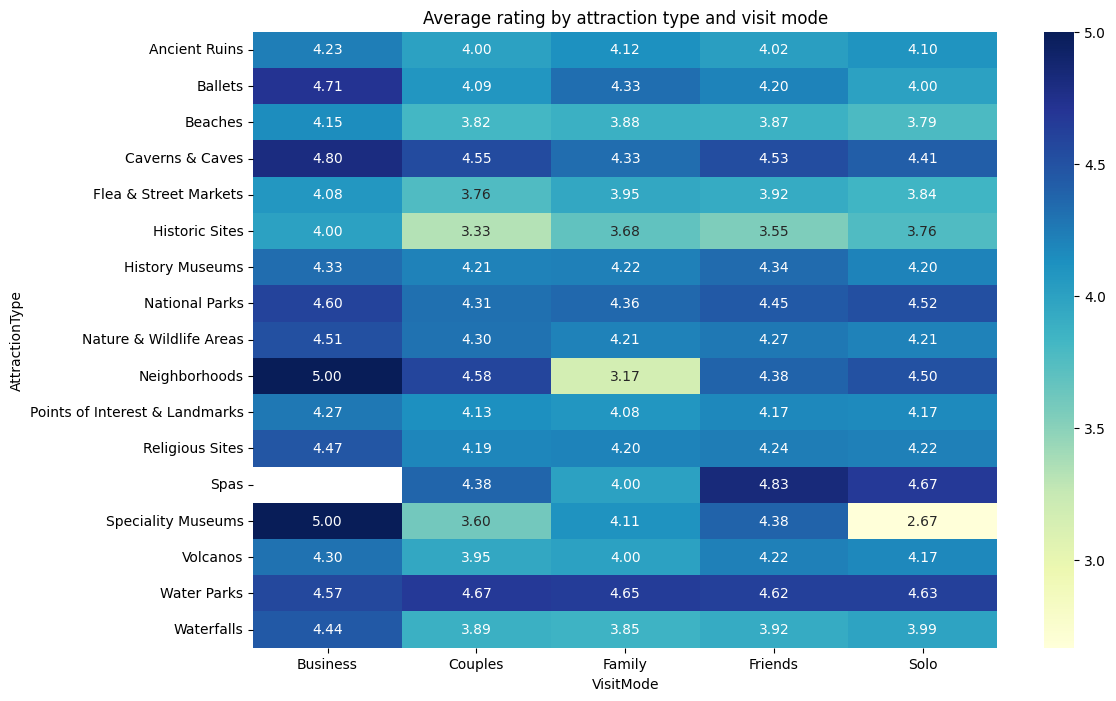

In [13]:
heatmap_data = pd.pivot_table(master, index='AttractionType', columns='VisitMode', values='Rating', aggfunc='mean')
plt.figure(figsize=(12,8))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Average rating by attraction type and visit mode'); plt.show()

## 7 Regression Rating Prediction

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
FEATURES = ['VisitYear','VisitMonth','UserContinent','UserRegion','UserCountry','UserCity','AttractionType','AttractionCity','AttractionCountry','AttractionRegion','AttractionContinent']
X = master[FEATURES].fillna('Unknown')
categorical = [c for c in FEATURES if c not in ['VisitYear','VisitMonth']]
preprocess = ColumnTransformer([('categorical',OneHotEncoder(handle_unknown='ignore'),categorical),('numeric','passthrough',['VisitYear','VisitMonth'])])
y_rating = master['Rating']
X_train,X_test,y_train,y_test = train_test_split(X,y_rating,test_size=.2,random_state=RANDOM_STATE)

In [15]:
models = {'Baseline':DummyRegressor(strategy='mean'), 'Random Forest':RandomForestRegressor(n_estimators=60,min_samples_leaf=2,random_state=RANDOM_STATE,n_jobs=-1)}
results, trained = [], {}
for name, model in models.items():
    pipeline = Pipeline([('preprocessing',preprocess),('model',model)]).fit(X_train,y_train)
    pred = pipeline.predict(X_test)
    results.append([name,mean_absolute_error(y_test,pred),mean_squared_error(y_test,pred),mean_squared_error(y_test,pred)**.5,r2_score(y_test,pred)])
    trained[name] = pipeline
comparison = pd.DataFrame(results,columns=['Model','MAE','MSE','RMSE','R2']).sort_values('RMSE')
display(comparison)
rating_model = trained[comparison.iloc[0]['Model']]

,Model,MAE,MSE,RMSE,R2
1,Random Forest,0.737412,0.904725,0.951170,0.039383
0,Baseline,0.759383,0.941818,0.970473,-0.000002


## 8 Classification Visit Mode

In [16]:
y_mode = master['VisitMode'].astype(str)
X_train,X_test,y_train,y_test = train_test_split(X,y_mode,test_size=.2,random_state=RANDOM_STATE,stratify=y_mode)
classifier = Pipeline([('preprocessing',preprocess),('model',RandomForestClassifier(n_estimators=60,min_samples_leaf=2,class_weight='balanced',random_state=RANDOM_STATE,n_jobs=-1))])
classifier.fit(X_train,y_train)
pred = classifier.predict(X_test)
print('Accuracy:',round(accuracy_score(y_test,pred),3))
display(pd.DataFrame(classification_report(y_test,pred,output_dict=True,zero_division=0)).T)

Accuracy: 0.379


,precision,recall,f1-score,support
Business,0.040534,0.656000,0.076350,125.000000
Couples,0.523264,0.538390,0.530719,4324.000000
Family,0.511072,0.379231,0.435390,3043.000000
Friends,0.328680,0.118319,0.174001,2189.000000
Solo,0.173221,0.204420,0.187532,905.000000
accuracy,0.378613,0.378613,0.378613,0.378613
macro avg,0.315354,0.379272,0.280798,10586.000000
weighted avg,0.443897,0.378613,0.394849,10586.000000


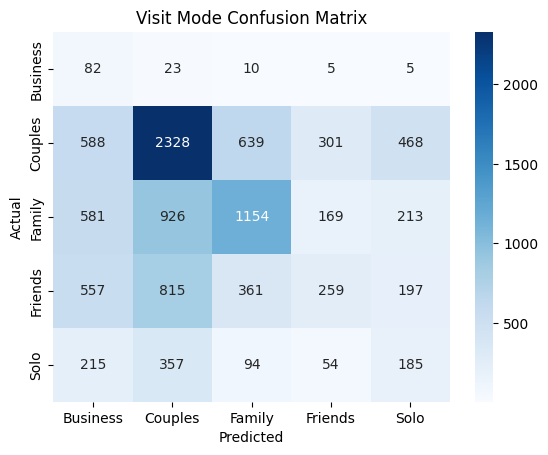

In [17]:
labels = sorted(y_mode.unique())
cm = confusion_matrix(y_test,pred,labels=labels)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=labels,yticklabels=labels)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Visit Mode Confusion Matrix'); plt.show()

## 9 Recommendation System

In [18]:
users, attractions, interactions = master.UserId.nunique(), master.AttractionId.nunique(), len(master)
sparsity = 1 - interactions/(users*attractions)
print(f'Users: {users}, attractions: {attractions}, interactions: {interactions}, sparsity: {sparsity:.2%}')
# Sparse interactions motivate a popularity baseline with content filters for cold-start users.

Users: 33530, attractions: 30, interactions: 52930, sparsity: 94.74%


In [19]:
global_mean = master['Rating'].mean()
recs = master.groupby(['AttractionId','Attraction','AttractionType','AttractionCity','AttractionCountry'],dropna=False).agg(interactions=('TransactionId','size'),mean_rating=('Rating','mean')).reset_index()
minimum = max(3,int(recs.interactions.quantile(.5)))
recs['recommendation_score'] = recs.interactions/(recs.interactions+minimum)*recs.mean_rating + minimum/(recs.interactions+minimum)*global_mean
recs['reason'] = 'Popularity and smoothed average rating'
display(recs.sort_values('recommendation_score',ascending=False).head(10))

,AttractionId,Attraction,AttractionType,AttractionCity,AttractionCountry,interactions,mean_rating,recommendation_score,reason
9,841,Waterbom Bali,Water Parks,Douala,Cameroon,6429,4.646601,4.619384,Popularity and smoothed average rating
11,888,Bromo Tengger Semeru National Park,National Parks,South Region,Cameroon,381,4.611549,4.385221,Popularity and smoothed average rating
2,640,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Douala,Cameroon,13198,4.267086,4.264032,Popularity and smoothed average rating
1,481,Nusa Dua Beach,Beaches,Douala,Cameroon,2104,4.275665,4.257659,Popularity and smoothed average rating
17,947,Mount Semeru Volcano,Volcanos,South Region,Cameroon,83,4.698795,4.254909,Popularity and smoothed average rating
20,1133,Jomblang Cave,Caverns & Caves,N'Djamena,Chad,135,4.503704,4.248576,Popularity and smoothed average rating
27,1278,Ullen Sentalu Museum,History Museums,N'Djamena,Chad,978,4.256646,4.229011,Popularity and smoothed average rating
8,824,Uluwatu Temple,Religious Sites,Douala,Cameroon,3359,4.219411,4.213154,Popularity and smoothed average rating
5,737,Tanah Lot Temple,Religious Sites,Douala,Cameroon,3352,4.194809,4.191039,Popularity and smoothed average rating
15,928,Khayangan Reflexology & Massage,Spas,South Region,Cameroon,28,4.571429,4.186162,Popularity and smoothed average rating


In [20]:
def recommend(attraction_type=None, city=None, k=10):
    result = recs.copy()
    if attraction_type: result = result[result.AttractionType == attraction_type]
    if city: result = result[result.AttractionCity == city]
    return result.sort_values('recommendation_score',ascending=False).head(k)
recommend(k=5)

,AttractionId,Attraction,AttractionType,AttractionCity,AttractionCountry,interactions,mean_rating,recommendation_score,reason
9,841,Waterbom Bali,Water Parks,Douala,Cameroon,6429,4.646601,4.619384,Popularity and smoothed average rating
11,888,Bromo Tengger Semeru National Park,National Parks,South Region,Cameroon,381,4.611549,4.385221,Popularity and smoothed average rating
2,640,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,Douala,Cameroon,13198,4.267086,4.264032,Popularity and smoothed average rating
1,481,Nusa Dua Beach,Beaches,Douala,Cameroon,2104,4.275665,4.257659,Popularity and smoothed average rating
17,947,Mount Semeru Volcano,Volcanos,South Region,Cameroon,83,4.698795,4.254909,Popularity and smoothed average rating


## 10 Conclusion

- The rating model provides a numeric rating estimate; app displays should clip it to 1-5.
- Visit-mode classification must be discussed with macro F1 and the confusion matrix, not accuracy alone.
- The recommendation baseline gives a sensible fallback for new users and sparse interaction histories.